# Binary Classification

In [1]:
import numpy as np
import pandas as pd
import os
import warnings
import io



In [2]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import Perceptron 
from sklearn.metrics import hinge_loss
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix,precision_recall_curve
from sklearn.metrics import precision_score, recall_score , classification_report
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_validate, cross_val_predict, GridSearchCV
from pprint import pprint
from sklearn.decomposition import PCA 

In [3]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

mpl.rc('figure', figsize=(8,6))
mpl.rc('axes', labelsize=14)
mpl.rc('xtick',labelsize=12)
mpl.rc('ytick',labelsize=12) 

np.random.seed(42)

In [4]:
def warn(*args,**kwargs):
    pass
warnings.warn=warn

In [7]:
X,y=fetch_openml('mnist_784',version=1, return_X_y=True)



In [8]:
X=X.to_numpy()
y=y.to_numpy()


In [9]:
target_name=np.unique(y)
print(f'No. of samples: {X.shape[0]}, type:{X.dtype}')
print(f'No. of featues: {X.shape[1]}')
print(f'Minimum {np.min(X)} , Maximum {np.max(X)}')
print(f'Number of classes: {len(target_name)}, dtype{y.dtype}')
print(f'Labels: {target_name}')


No. of samples: 70000, type:int64
No. of featues: 784
Minimum 0 , Maximum 255
Number of classes: 10, dtypeobject
Labels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


In [10]:
X=MinMaxScaler().fit_transform(X)
print(f"Minimum:{np.min(X)}, Maximum{np.max(X)}")

Minimum:0.0, Maximum1.0


# Data Visualization

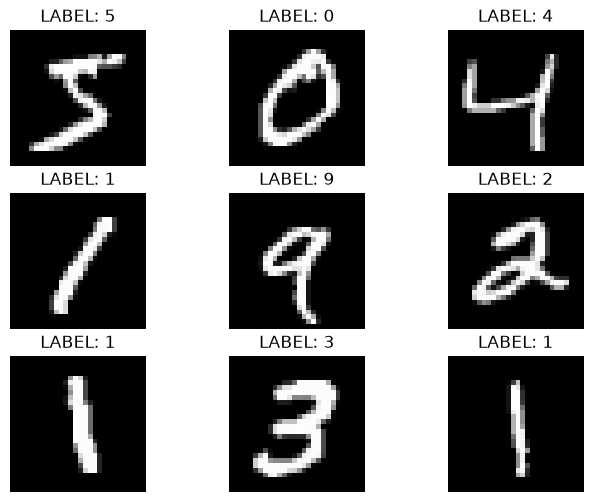

In [25]:
num_images=9
factor =np.int64(np.sqrt(num_images))
fig,axis=plt.subplots(nrows=factor,ncols=factor, figsize=(8,6) )
idx_offset=0
for i in range(factor):
    index=idx_offset+ i*(factor)
    for j in range(factor):
        axis[i,j].imshow(X[index +j].reshape(28,28),cmap='grey')
        axis[i,j].set_title(f'LABEL: {str(y[index+j])}')
        axis[i,j].set_axis_off()

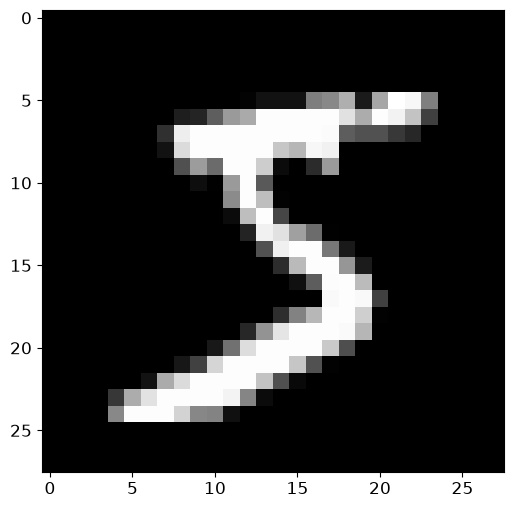

In [26]:
plt.figure(figsize=(6,6))
plt.imshow(X[0].reshape(28,28),cmap='gray')
plt.show()


# Data Spliting

In [27]:
x_train,x_test,y_train,y_test=X[:60000],X[60000:],y[:60000],y[60000:]

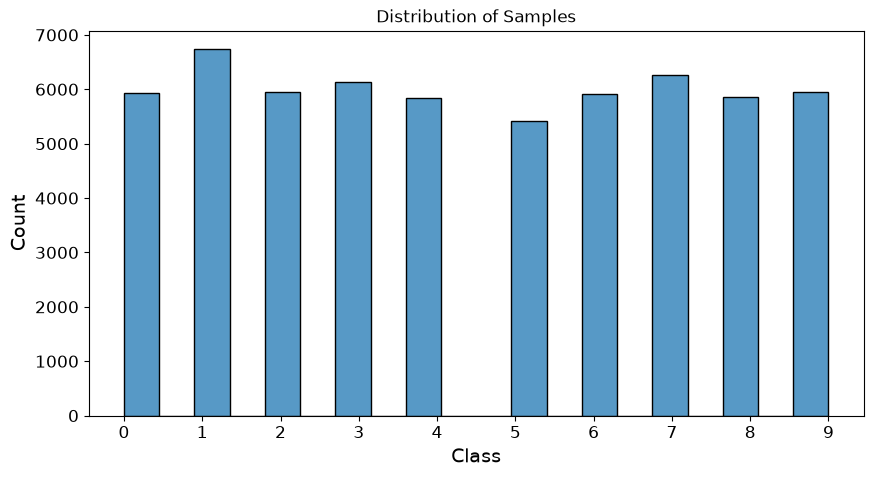

In [33]:
plt.figure(figsize=(10,5))
sns.histplot(data=np.int8(y_train),binwidth=0.45,bins=11)
plt.xticks(ticks=[0,1,2,3,4,5,6,7,8,9],labels=[0,1,2,3,4,5,6,7,8,9])
plt.xlabel('Class')
plt.title('Distribution of Samples')
plt.show()

# Binary Classification: 0-Detector

In [35]:
y_train_0= -1*np.ones((len(y_train)))
y_test_0= -1*np.ones((len(y_test)))

indx_0 =np.where(y_train=='0')
y_train_0[indx_0]=1
indx_0=np.where(y_test == '0')
y_test_0[indx_0]=1

print(y_train)
print(y_train_0)

['5' '0' '4' ... '5' '6' '8']
[-1.  1. -1. ... -1. -1. -1.]


In [37]:
print(np.where(y_train=='0'))
print(np.where(y_train_0 == 1))

(array([    1,    21,    34, ..., 59952, 59972, 59987], shape=(5923,)),)
(array([    1,    21,    34, ..., 59952, 59972, 59987], shape=(5923,)),)


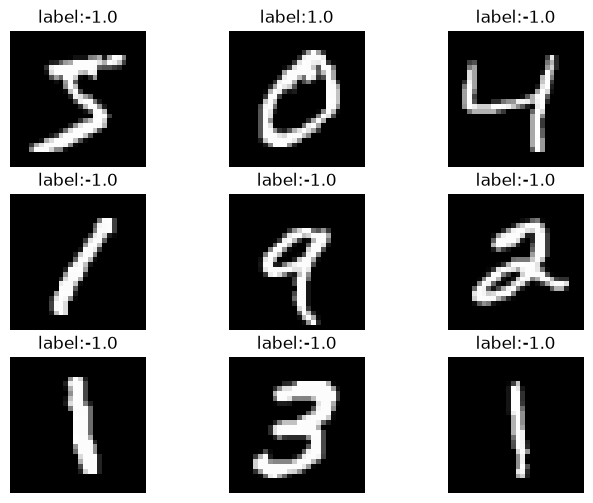

In [39]:
num_images=9
factor=np.int64(np.sqrt(num_images))
fig, axis=plt.subplots(nrows=factor,ncols=factor,figsize=(8,6))
idx_offset=0
for i in range(factor):
    index=idx_offset +i*(factor)
    for j in range(factor):
        axis[i,j].imshow(X[index +j].reshape(28,28),cmap='gray')
        axis[i,j].set_title(f'label:{str(y_train_0[index +j])}')
        axis[i,j].set_axis_off()

Testing PCA 


In [42]:
from sklearn.decomposition import PCA 
from sklearn.metrics import f1_score,precision_score,recall_score
pca=PCA(n_components=10,random_state=1)
p=pca.fit(x_train)
x_train1_reduced=p.transform(x_train)
clf=Perceptron(random_state=42,eta0=1,max_iter=100,shuffle=True,validation_fraction=0.1,fit_intercept=True, penalty=None, warm_start=False)
clf.fit(x_train1_reduced,y_train_0)
f1_a1=[]
f1_a2=[]
for i in range(1,100):
    x_test1_reduced_0=p.transform(x_test[0:i*10,:])
    x_test1_reduced_1=p.fit(x_test[0:i*10,:]).transform(x_test[0:i*10,:])
    y_pred1=clf.predict(x_test1_reduced_0)
    f1_a1.append(f1_score(y_test_0[0:i*10],y_pred1))
    y_pred1=clf.predict(x_test1_reduced_1)
    f1_a2.append(f1_score(y_test_0[0:i*10],y_pred1))

print(f1_a1)
print(f1_a2)



[1.0, 0.3333333333333333, 0.0, 0.6, 0.8, 0.5333333333333333, 0.3, 0.5263157894736842, 0.4444444444444444, 0.6666666666666666, 0.43478260869565216, 0.08333333333333333, 0.24, 0.4827586206896552, 0.27586206896551724, 0.2, 0.375, 0.4, 0.12903225806451613, 0.4864864864864865, 0.391304347826087, 0.32653061224489793, 0.046511627906976744, 0.05128205128205128, 0.09302325581395349, 0.044444444444444446, 0.0, 0.10714285714285714, 0.0, 0.03333333333333333, 0.03389830508474576, 0.06666666666666667, 0.09836065573770492, 0.125, 0.09230769230769231, 0.0625, 0.13513513513513514, 0.136986301369863, 0.13333333333333333, 0.20253164556962025, 0.14814814814814814, 0.6493506493506493, 0.09876543209876543, 0.12195121951219512, 0.09195402298850575, 0.13043478260869565, 0.21739130434782608, 0.2222222222222222, 0.20618556701030927, 0.2, 0.19607843137254902, 0.12, 0.10204081632653061, 0.09900990099009901, 0.07692307692307693, 0.10810810810810811, 0.09090909090909091, 0.16216216216216217, 0.15384615384615385, 0.

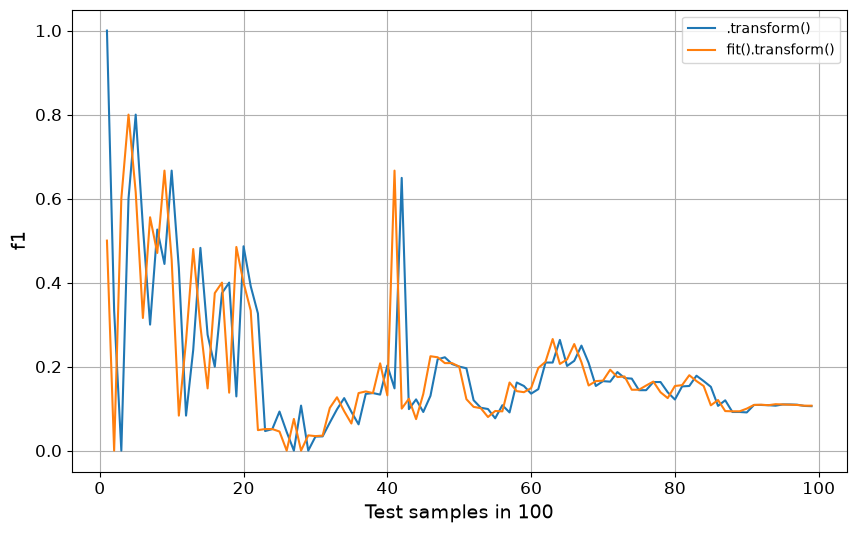

: 

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(np.arange(1,100),f1_a1,label='.transform()')
plt.plot(np.arange(1,100),f1_a2,label="fit().transform()")
plt.xlabel('Test samples in 100')
plt.ylabel('f1')
plt.grid(True)
plt.legend()